In [ ]:
import os

DATA_DIR     = "../data/dataset"   
FEATURE_COLS = ["temperature", "pressure", "humidity", "gas_resistance"]
SEQ_LEN      = 10
N_FEATURES   = len(FEATURE_COLS)  # 4

CONDITION_CLEAN = "closed_container"
CONDITION_NOISY = "open_room"

T          = 300
BETA_START = 1e-4
BETA_END   = 0.02

EPOCHS_CLF   = 40
EPOCHS_SCORE = 80
BATCH_SIZE   = 128
LR           = 3e-4

SEED = 67
import numpy as np; np.random.seed(SEED)
import tensorflow as tf; tf.random.set_seed(SEED)
print("Config OK")

Config OK


In [ ]:
import pandas as pd
import glob


def load_sequences(data_dir, condition_substr, feature_cols, seq_len):
    all_X, all_y = [], []
    for fp in sorted(glob.glob(os.path.join(data_dir, "**", "*.csv"), recursive=True)):
        if condition_substr not in os.path.basename(fp):
            continue
        df = pd.read_csv(fp)
        df["gas_resistance"] = np.log1p(df["gas_resistance"])  # log-compress
        grouped = df.groupby(["sensor_index", "fingerprint_index"])
        for (sensor, fp_idx), grp in grouped:
            grp = grp.sort_values("position")
            if len(grp) != seq_len:
                continue
            all_X.append(grp[feature_cols].values.astype(np.float32))
            all_y.append(grp["label"].iloc[0])
    return np.stack(all_X), np.array(all_y)


X_clean, y_clean = load_sequences(DATA_DIR, CONDITION_CLEAN, FEATURE_COLS, SEQ_LEN)
X_noisy, y_noisy = load_sequences(DATA_DIR, CONDITION_NOISY, FEATURE_COLS, SEQ_LEN)

print(f"Clean sequences (closed container): {X_clean.shape}")
print(f"Noisy sequences (open room):        {X_noisy.shape}")
print(f"Classes: {np.unique(y_clean)}")

for cls in np.unique(y_clean):
    print(f"  {cls}: {(y_clean==cls).sum()} clean  |  {(y_noisy==cls).sum()} open-room")

Clean sequences (closed container): (2839, 10, 4)
Noisy sequences (open room):        (2137, 10, 4)
Classes: ['air' 'basil' 'cinnamon' 'rosemary']
  air: 696 clean  |  741 open-room
  basil: 728 clean  |  679 open-room
  cinnamon: 684 clean  |  717 open-room
  rosemary: 731 clean  |  0 open-room


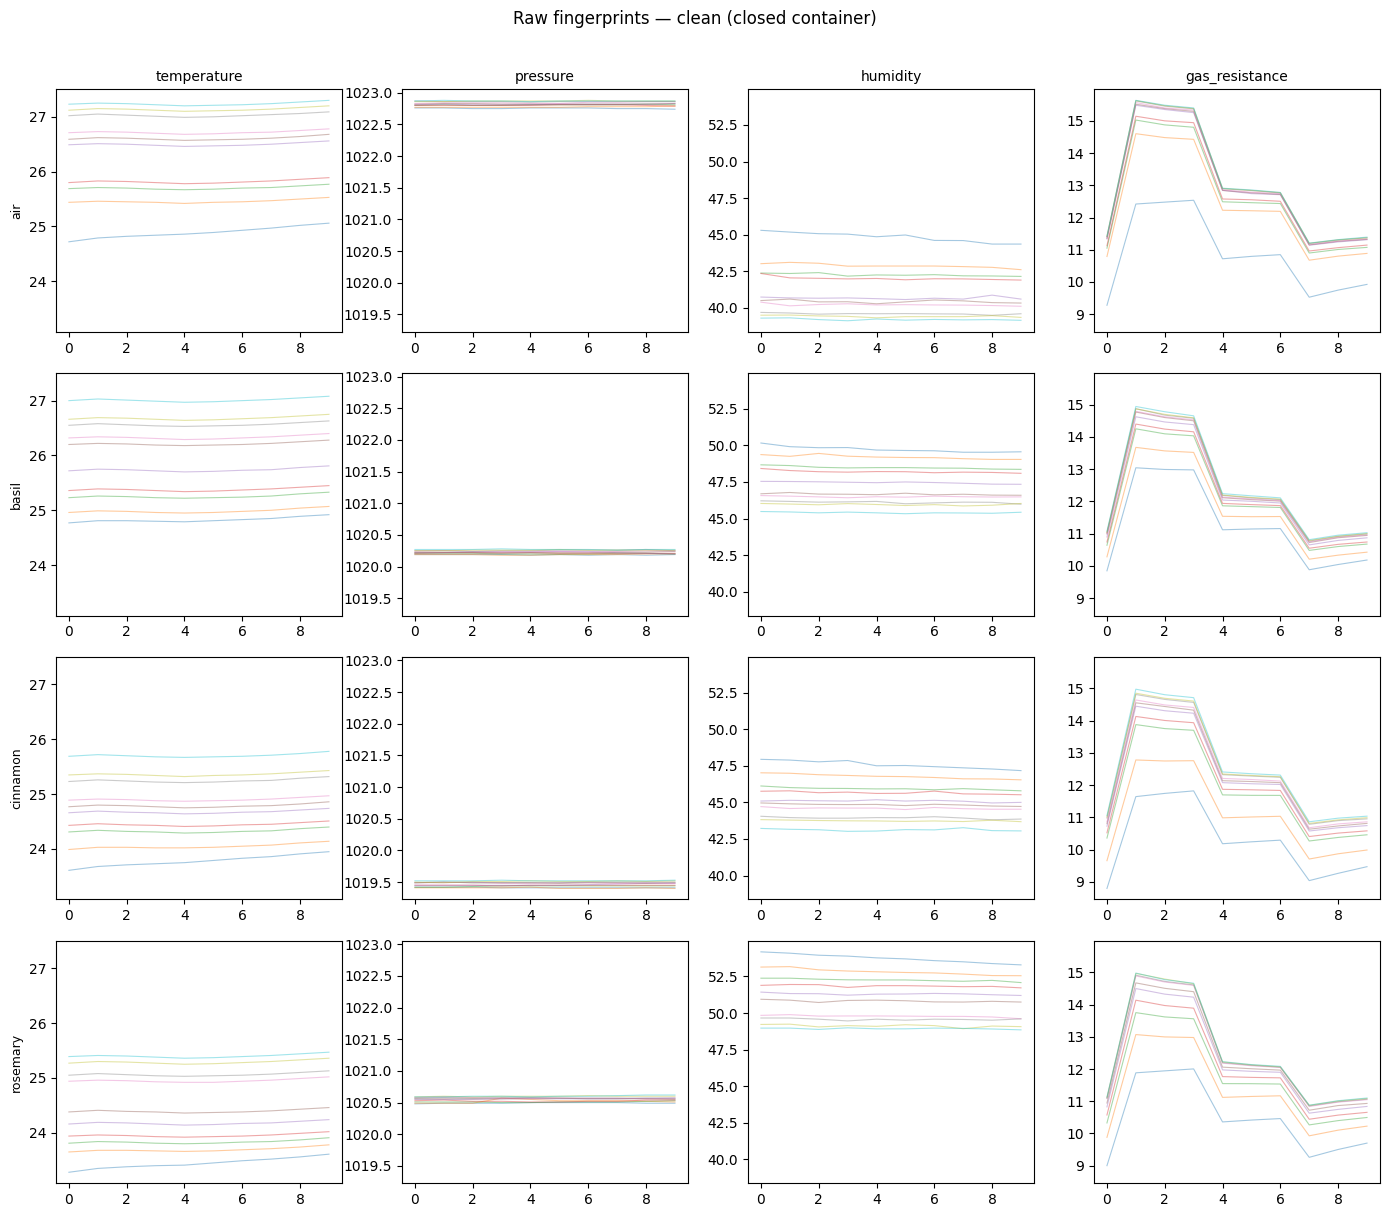

In [ ]:
import matplotlib.pyplot as plt

classes = np.unique(y_clean)
fig, axes = plt.subplots(len(classes), N_FEATURES, figsize=(14, 3 * len(classes)), sharey="col")

for r, cls in enumerate(classes):
    idx    = np.where(y_clean == cls)[0]
    sample = X_clean[idx[:10]]
    for c, feat in enumerate(FEATURE_COLS):
        ax = axes[r, c]
        for s in sample:
            ax.plot(s[:, c], alpha=0.4, lw=0.8)
        if r == 0: ax.set_title(feat, fontsize=10)
        if c == 0: ax.set_ylabel(cls, fontsize=9)

plt.suptitle("Fingerprints - closed container", y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

N, S, F = X_clean.shape

scaler = StandardScaler()
X_clean_norm = scaler.fit_transform(X_clean.reshape(-1, F)).reshape(N, S, F).astype(np.float32)

Nn = X_noisy.shape[0]
X_noisy_norm = scaler.transform(X_noisy.reshape(-1, F)).reshape(Nn, S, F).astype(np.float32)

le      = LabelEncoder()
y_enc   = le.fit_transform(y_clean)
NUM_CLASSES = len(le.classes_)
print(f"Classes ({NUM_CLASSES}): {le.classes_}")

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clean_norm, y_enc, test_size=0.15, stratify=y_enc, random_state=SEED
)
print(f"Train: {X_tr.shape}  Test: {X_te.shape}")

Classes (4): ['air' 'basil' 'cinnamon' 'rosemary']
Train: (2413, 10, 4)  Test: (426, 10, 4)


In [5]:
# ── 4. LSTM Classifier ────────────────────────────────────────────────────────
from tensorflow import keras
from tensorflow.keras import layers


def build_classifier(seq_len, n_features, n_classes):
    model = keras.Sequential([
        keras.Input(shape=(seq_len, n_features)),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32, return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ], name="LSTM_Classifier")
    model.compile(
        optimizer=keras.optimizers.Adam(LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


clf = build_classifier(SEQ_LEN, N_FEATURES, NUM_CLASSES)
clf.summary()

Model: "LSTM_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,268 (122.14 KB)

 Trainable params: 31,268 (122.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8673 - loss: 0.3214 - val_accuracy: 0.8471 - val_loss: 0.3192
Epoch 2/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8706 - loss: 0.3138 - val_accuracy: 0.8678 - val_loss: 0.3156
Epoch 3/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8609 - loss: 0.3198 - val_accuracy: 0.8636 - val_loss: 0.3119
Epoch 4/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8715 - loss: 0.3055 - val_accuracy: 0.8512 - val_loss: 0.3070
Epoch 5/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8701 - loss: 0.3014 - val_accuracy: 0.8554 - val_loss: 0.3318
Epoch 6/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8655 - loss: 0.3067 - val_accuracy: 0.8554 - val_loss: 0.3050
Epoch 7/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8678 - loss: 0.3035 - val_accuracy: 0.8595 - val_loss: 0.2980
Epoch 8/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8696 - loss: 0.2959 - val_accuracy: 0.8760 - v

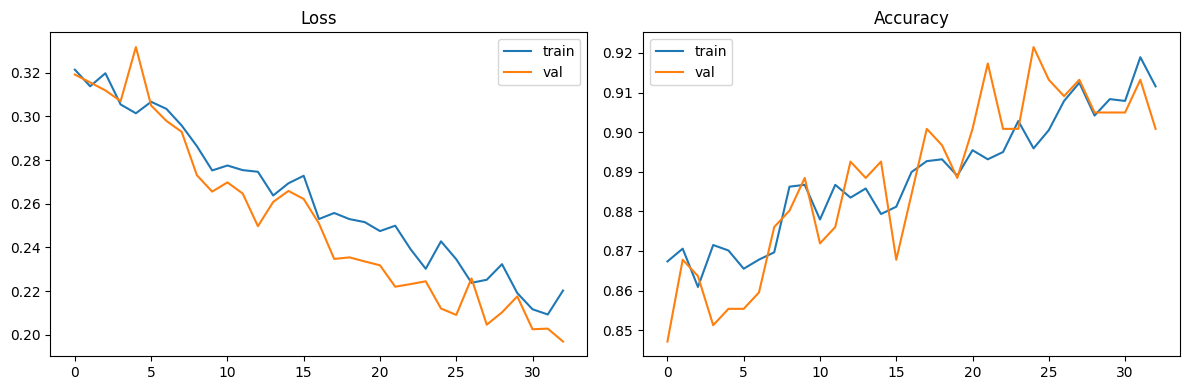

In [ ]:
hist = clf.fit(
    X_tr, y_tr,
    validation_split=0.1,
    epochs=EPOCHS_CLF,
    batch_size=BATCH_SIZE,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=8, restore_best_weights=True
    )],
    verbose=1
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist.history["loss"], label="train"); ax1.plot(hist.history["val_loss"], label="val")
ax1.set_title("Loss"); ax1.legend()
ax2.plot(hist.history["accuracy"], label="train"); ax2.plot(hist.history["val_accuracy"], label="val")
ax2.set_title("Accuracy"); ax2.legend()
plt.tight_layout(); plt.show()

Baseline test accuracy (clean data): 0.8944

              precision    recall  f1-score   support

         air       0.97      1.00      0.99       104
       basil       0.88      0.72      0.79       109
    cinnamon       1.00      0.97      0.99       103
    rosemary       0.76      0.90      0.82       110

    accuracy                           0.89       426
   macro avg       0.90      0.90      0.90       426
weighted avg       0.90      0.89      0.89       426



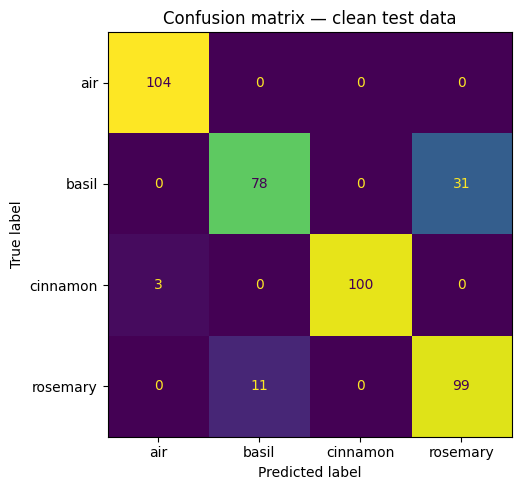

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

y_pred = np.argmax(clf.predict(X_te, verbose=0), axis=1)
acc_baseline = accuracy_score(y_te, y_pred)
print(f"Baseline test accuracy (clean data): {acc_baseline:.4f}\n")
print(classification_report(y_te, y_pred, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred), display_labels=le.classes_).plot(ax=ax, colorbar=False)
ax.set_title("Confusion matrix — clean test data")
plt.tight_layout(); plt.show()

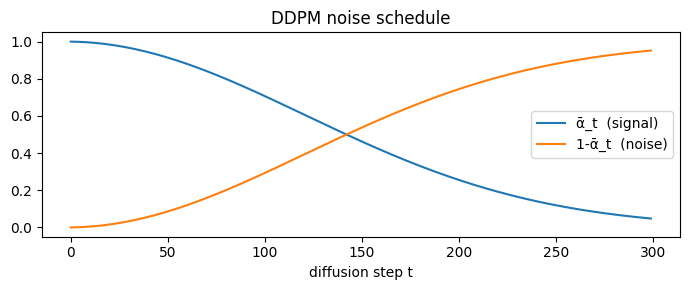

Signal half-life: t = 143 / 300


In [ ]:
betas      = np.linspace(BETA_START, BETA_END, T, dtype=np.float32)
alphas     = 1.0 - betas
alpha_bars = np.cumprod(alphas)
sqrt_ab      = np.sqrt(alpha_bars)
sqrt_one_mab = np.sqrt(1 - alpha_bars)

plt.figure(figsize=(7, 3))
plt.plot(alpha_bars, label="ᾱ_t  (signal)"); plt.plot(1 - alpha_bars, label="1-ᾱ_t  (noise)")
plt.xlabel("diffusion step t"); plt.title("DDPM noise schedule"); plt.legend()
plt.tight_layout(); plt.show()
print(f"Signal half-life: t = {np.argmax(alpha_bars < 0.5)} / {T}")

In [12]:
# ── 8. Score network ──────────────────────────────────────────────────────────
#
# Input : (x_t [B,S,F],  t_emb [B,32])
# Output: epsilon-hat [B,S,F]  — predicted noise at each heater step
#
# The LSTM is key: heater steps within a BME688 fingerprint are ordered
# (temperature ramps up and down), so the noise too has temporal structure.

T_EMB_DIM  = 32


def sinusoidal_embedding(t_int, dim=T_EMB_DIM):
    half  = dim // 2
    freqs = tf.exp(-np.log(10000.0) * tf.cast(tf.range(half), tf.float32) / float(half - 1))
    args  = tf.cast(t_int, tf.float32)[:, None] * freqs[None, :]
    return tf.concat([tf.sin(args), tf.cos(args)], axis=-1)


def build_score_network(seq_len, n_features, t_emb_dim=T_EMB_DIM, lstm_units=64):
    x_in  = keras.Input(shape=(seq_len, n_features), name="x_t")
    t_in  = keras.Input(shape=(t_emb_dim,),          name="t_emb")

    t_tld = layers.RepeatVector(seq_len)(t_in)           # [B, S, t_emb_dim]
    z     = layers.Concatenate(axis=-1)([x_in, t_tld])  # [B, S, F + t_emb_dim]

    z = layers.LSTM(lstm_units, return_sequences=True)(z)
    z = layers.Dropout(0.1)(z)
    z = layers.LSTM(lstm_units, return_sequences=True)(z)

    z    = layers.TimeDistributed(layers.Dense(lstm_units // 2, activation="swish"))(z)
    out  = layers.TimeDistributed(layers.Dense(n_features))(z)  # [B, S, F]

    return keras.Model(inputs=[x_in, t_in], outputs=out, name="ScoreNet")


score_net = build_score_network(SEQ_LEN, N_FEATURES)
score_net.summary()

Model: "ScoreNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ t_emb (InputLayer)  │ (None, 32)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ x_t (InputLayer)    │ (None, 10, 4)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 10, 32)    │          0 │ t_emb[0][0]       │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 10, 36)    │          0 │ x_t[0][0],        │
│ (Concatenate)       │                   │            │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 10, 64)    │     25,856 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 10, 64)    │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 10, 64)    │     33,024 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 10, 32)    │      2,080 │ lstm_3[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 10, 4)     │        132 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 61,092 (238.64 KB)

 Trainable params: 61,092 (238.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch  10/80  loss = 0.84850
Epoch  20/80  loss = 0.67100
Epoch  30/80  loss = 0.60548
Epoch  40/80  loss = 0.57213
Epoch  50/80  loss = 0.55054
Epoch  60/80  loss = 0.52903
Epoch  70/80  loss = 0.54768
Epoch  80/80  loss = 0.50967


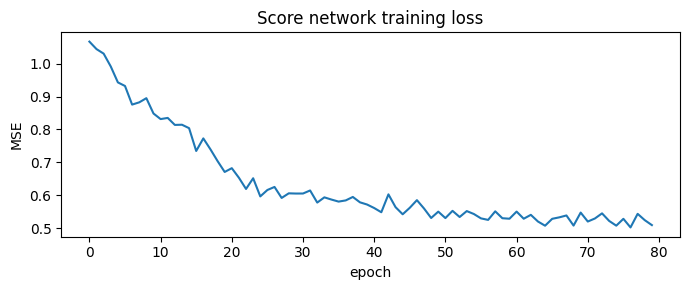

In [13]:
# ── 9. Train score network ────────────────────────────────────────────────────
#
# Noise = λ · (real_open_room - clean)  +  (1-λ) · Gaussian,   λ ~ Beta(0.5, 0.5)
# This teaches the denoiser to handle STRUCTURED environmental noise, not just white noise.

score_opt = keras.optimizers.Adam(LR)

@tf.function
def score_train_step(x0, t_int, eps_mix):
    sab  = tf.gather(tf.constant(sqrt_ab),      t_int)[:, None, None]
    smab = tf.gather(tf.constant(sqrt_one_mab), t_int)[:, None, None]
    x_t  = sab * x0 + smab * eps_mix
    t_emb = sinusoidal_embedding(t_int)
    with tf.GradientTape() as tape:
        eps_hat = score_net([x_t, t_emb], training=True)
        loss    = tf.reduce_mean(tf.square(eps_hat - eps_mix))
    grads = tape.gradient(loss, score_net.trainable_variables)
    score_opt.apply_gradients(zip(grads, score_net.trainable_variables))
    return loss


rng2 = np.random.default_rng(SEED)
score_losses = []

for epoch in range(EPOCHS_SCORE):
    perm = rng2.permutation(N)
    ep_losses = []

    for start in range(0, N, BATCH_SIZE):
        b_idx = perm[start:start + BATCH_SIZE]
        x0    = X_clean_norm[b_idx]
        B     = len(x0)

        t_np   = rng2.integers(0, T, B).astype(np.int32)
        eps_g  = rng2.standard_normal(x0.shape).astype(np.float32)
        n_idx  = rng2.integers(0, Nn, B)
        eps_r  = X_noisy_norm[n_idx] - x0
        lam    = rng2.beta(0.5, 0.5, (B, 1, 1)).astype(np.float32)
        eps_mx = (1 - lam) * eps_g + lam * eps_r

        loss = score_train_step(tf.constant(x0), tf.constant(t_np), tf.constant(eps_mx))
        ep_losses.append(float(loss))

    mean_loss = float(np.mean(ep_losses))
    score_losses.append(mean_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS_SCORE}  loss = {mean_loss:.5f}")

plt.figure(figsize=(7, 3))
plt.plot(score_losses); plt.xlabel("epoch"); plt.ylabel("MSE")
plt.title("Score network training loss"); plt.tight_layout(); plt.show()

In [14]:
# ── 10. Samplers ──────────────────────────────────────────────────────────────

def ddpm_denoise(x_in, n_steps=T):
    """Full stochastic DDPM reverse. x_in: [B,S,F] or [S,F]."""
    single = x_in.ndim == 2
    x = (x_in[None] if single else x_in.copy()).astype(np.float32)
    for t in reversed(range(n_steps)):
        t_b   = np.full(len(x), t, dtype=np.int32)
        t_emb = sinusoidal_embedding(tf.constant(t_b)).numpy()
        eps_h = score_net.predict([x, t_emb], verbose=0)
        mu    = (x - betas[t] / sqrt_one_mab[t] * eps_h) / np.sqrt(alphas[t])
        x     = mu + (np.sqrt(betas[t]) * np.random.randn(*x.shape) if t > 0 else 0)
    return x[0] if single else x


def ddim_denoise(x_in, n_steps=30):
    """Deterministic DDIM with n_steps << T. ~10x faster than DDPM. x_in: [B,S,F] or [S,F]."""
    single = x_in.ndim == 2
    x = (x_in[None] if single else x_in.copy()).astype(np.float32)
    steps = np.linspace(T - 1, 0, n_steps, dtype=int)
    for i, t in enumerate(steps):
        t_next = steps[i + 1] if i + 1 < len(steps) else 0
        t_b    = np.full(len(x), t, dtype=np.int32)
        t_emb  = sinusoidal_embedding(tf.constant(t_b)).numpy()
        eps_h  = score_net.predict([x, t_emb], verbose=0)
        x0p    = (x - sqrt_one_mab[t] * eps_h) / sqrt_ab[t]  # predicted x0
        x      = sqrt_ab[t_next] * x0p + sqrt_one_mab[t_next] * eps_h
    return x[0] if single else x


print("DDPM and DDIM samplers ready.")

DDPM and DDIM samplers ready.


In [ ]:
# ── 12. Synthetic noise ablation ──────────────────────────────────────────────

scenarios = {
    "A: mild Gaussian      (t=20%)": (int(0.20 * T), "gauss"),
    "B: moderate Gaussian  (t=50%)": (int(0.50 * T), "gauss"),
    "C: heavy + room noise (t=70%)": (int(0.70 * T), "mixed"),
}

print(f"{'Scenario':<42} {'Noisy':>7} {'Denoised':>10} {'Δ':>7}")
print("-" * 70)

for name, (t_c, ntype) in scenarios.items():
    rng3  = np.random.default_rng(0)
    eps_g = rng3.standard_normal(X_te.shape).astype(np.float32)

    if ntype == "mixed":
        ni    = rng3.integers(0, Nn, len(X_te))
        eps_r = X_noisy_norm[ni] - X_te
        lam   = rng3.beta(0.5, 0.5, (len(X_te), 1, 1)).astype(np.float32)
        eps   = (1 - lam) * eps_g + lam * eps_r
    else:
        eps = eps_g

    Xc = sqrt_ab[t_c] * X_te + sqrt_one_mab[t_c] * eps
    Xd = ddim_denoise(Xc, n_steps=40)

    acc_n = accuracy_score(y_te, np.argmax(clf.predict(Xc, verbose=0), axis=1))
    acc_d = accuracy_score(y_te, np.argmax(clf.predict(Xd, verbose=0), axis=1))
    print(f"{name:<42} {acc_n:>7.3f} {acc_d:>10.3f} {acc_d-acc_n:>+7.3f}")

print(f"\nBaseline (clean test data): {acc_baseline:.3f}")

Scenario                                     Noisy   Denoised       Δ
----------------------------------------------------------------------
A: mild Gaussian      (t=20%)                0.585      0.401  -0.183
B: moderate Gaussian  (t=50%)                0.347      0.359  +0.012
C: heavy + room noise (t=70%)                0.218      0.256  +0.038

Baseline (clean test data): 0.894


In [ ]:
y_noisy_enc = le.transform(y_noisy)

acc_raw = accuracy_score(y_noisy_enc, np.argmax(clf.predict(X_noisy_norm, verbose=0), axis=1))
print(f"Accuracy on raw open-room fingerprints : {acc_raw:.4f}")

X_noisy_denoised = ddim_denoise(X_noisy_norm, n_steps=40)
acc_den = accuracy_score(y_noisy_enc, np.argmax(clf.predict(X_noisy_denoised, verbose=0), axis=1))
print(f"Accuracy after diffusion denoising     : {acc_den:.4f}")
print(f"Recovery Δ                             : {acc_den - acc_raw:+.4f}")

print()
print(classification_report(
    y_noisy_enc,
    np.argmax(clf.predict(X_noisy_denoised, verbose=0), axis=1),
    target_names=le.classes_
))

Accuracy on raw open-room fingerprints : 0.3191
Accuracy after diffusion denoising     : 0.4006
Recovery Δ                             : +0.0814

              precision    recall  f1-score   support

         air       0.53      0.58      0.55       741
       basil       0.39      0.16      0.22       679
    cinnamon       0.33      0.45      0.38       717
    rosemary       0.00      0.00      0.00         0

    accuracy                           0.40      2137
   macro avg       0.31      0.30      0.29      2137
weighted avg       0.42      0.40      0.39      2137



c:\Users\dhyey\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dhyey\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dhyey\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri